#### Multi-class classification

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.base import clone

import warnings
warnings.filterwarnings("ignore")


In [3]:
war_date = pd.to_datetime("2022-02-24")

windows = [
    ("pre_6m", war_date - pd.DateOffset(months=6),  war_date),
    ("post_0-6m", war_date, war_date + pd.DateOffset(months=6)),
    ("post_6-12m", war_date + pd.DateOffset(months=6),  war_date + pd.DateOffset(months=12)),
    ("post_12-18m", war_date + pd.DateOffset(months=12), war_date + pd.DateOffset(months=18)),
    ("post_18-24m", war_date + pd.DateOffset(months=18), war_date + pd.DateOffset(months=24)),
    ("post_24-30m", war_date + pd.DateOffset(months=24), war_date + pd.DateOffset(months=30))
]
window_labels = [w[0] for w in windows]

#### Features

In [4]:
features = [
    "donor_daily_message_count",
    "donor_daily_avg_length",
    "daily_active_chats",
    "night_share",
    "words_sent_over_words_received",
    "n_messages_received"
]

In [5]:
cv_folds = 5

In [6]:
exclude_ukr = [
    "06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f",
    "179bbc95-ec8b-4a65-98c5-5d3b566806fa",
]
exclude_de = [
    "b7a3d9c4-ec90-4241-bc76-f66205049400",
    "2fa4bc24-8f4d-46f1-ac8e-1deafe7479a5",
]

#### Models

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Linear SVM": LinearSVC(max_iter=2000, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}


#### German data

In [8]:
overview = pd.read_excel(control_data / "overview-clean-04-AB.xlsx")
overview["min_message_date"] = pd.to_datetime(overview["min_message_date"])
overview["max_message_date"] = pd.to_datetime(overview["max_message_date"])

full_start = war_date - pd.DateOffset(months=6)
full_end = war_date + pd.DateOffset(months=30)

valid_donors_de = overview[
    (overview["min_message_date"] <= full_start) &
    (overview["max_message_date"] >= full_end) &
    (~overview["donation_id"].isin(exclude_de))
].copy()

print(f"German donors covering all 6 windows: {len(valid_donors_de)}")

valid_donors_de = (
    valid_donors_de
    .sample(n=22, random_state=42)
)["donation_id"].tolist()

print(f"German donors after random sample: {len(valid_donors_de)}")

df_de = pd.read_csv(control_data / "text_messages_04-AB.csv")
df_de["datetime"] = pd.to_datetime(df_de["datetime"])
df_de["date"] = df_de["datetime"].dt.date
df_de["hour"] = df_de["datetime"].dt.hour
df_de = df_de[df_de["donation_id"].isin(valid_donors_de)]

donor_sender_de = (
    df_de.groupby(["donation_id", "sender_id"])["conversation_id"]
    .nunique().reset_index()
    .sort_values(["donation_id", "conversation_id"], ascending=[True, False])
    .groupby("donation_id").first().reset_index()
    .rename(columns={"sender_id": "donor_sender_id"})
)[["donation_id", "donor_sender_id"]]

df_de = df_de.merge(donor_sender_de, on="donation_id", how="left")
df_de["is_donor"] = (df_de["sender_id"] == df_de["donor_sender_id"]).astype(int)

# top-5 chats per donor
top5_de = (
    df_de.groupby(["donation_id", "conversation_id"]).size()
    .reset_index(name="n_messages")
    .sort_values(["donation_id", "n_messages"], ascending=[True, False])
    .groupby("donation_id").head(5)
)[["donation_id", "conversation_id"]]

df_de = df_de.merge(top5_de, on=["donation_id", "conversation_id"], how="inner")
print(f"German rows after top-5 filter: {len(df_de):,}")


German donors covering all 6 windows: 37
German donors after random sample: 22
German rows after top-5 filter: 1,408,531


In [9]:
donor_msg_de = df_de[df_de["is_donor"] == 1].copy()

msg_count_de = donor_msg_de.groupby(["donation_id", "date"]).size().reset_index(name="donor_daily_message_count")
avg_len_de = donor_msg_de.groupby(["donation_id", "date"])["word_count"].mean().reset_index().rename(columns={"word_count": "donor_daily_avg_length"})
active_chats_de = df_de.groupby(["donation_id", "date"])["conversation_id"].nunique().reset_index().rename(columns={"conversation_id": "daily_active_chats"})

donor_msg_de["is_night"] = ((donor_msg_de["hour"] >= 0) & (donor_msg_de["hour"] < 6)).astype(int)
night_share_de = donor_msg_de.groupby(["donation_id", "date"])["is_night"].mean().reset_index().rename(columns={"is_night": "night_share"})

received_de = df_de[df_de["is_donor"] == 0]
chat_to_donor_de = df_de[df_de["is_donor"] == 1][["donation_id", "conversation_id"]].drop_duplicates().rename(columns={"donation_id": "donor_id"})
recv_de = received_de.merge(chat_to_donor_de, on="conversation_id", how="inner")
n_received_de = recv_de.groupby(["donor_id", "date"]).size().reset_index(name="n_messages_received").rename(columns={"donor_id": "donation_id"})

words_sent_de = donor_msg_de.groupby(["donation_id", "date"])["word_count"].sum().reset_index().rename(columns={"word_count": "words_sent"})
words_recv_de = recv_de.groupby(["donor_id", "date"])["word_count"].sum().reset_index().rename(columns={"donor_id": "donation_id", "word_count": "words_received"})

df_features_de = reduce(lambda l, r: pd.merge(l, r, on=["donation_id", "date"], how="outer"),
    [msg_count_de, avg_len_de, active_chats_de, night_share_de, n_received_de, words_sent_de, words_recv_de]
).fillna(0)
df_features_de["date"] = pd.to_datetime(df_features_de["date"])
df_features_de["words_sent_over_words_received"] = df_features_de["words_sent"] / (df_features_de["words_received"] + 1e-9)
print(f"German features shape: {df_features_de.shape}")


German features shape: (44848, 10)


#### Ukrainian data

In [10]:
df_ukr = pd.read_csv(filtered_data / "text_messages_filtered.csv")
df_ukr["datetime"] = pd.to_datetime(df_ukr["datetime"])
df_ukr["date"] = df_ukr["datetime"].dt.date
df_ukr["hour"] = df_ukr["datetime"].dt.hour
df_ukr = df_ukr[~df_ukr["donation_id"].isin(exclude_ukr)]

# top-5 chats per donor
top5_ukr = (
    df_ukr.groupby(["donation_id", "conversation_id"]).size()
    .reset_index(name="n_messages")
    .sort_values(["donation_id", "n_messages"], ascending=[True, False])
    .groupby("donation_id").head(5)
)[["donation_id", "conversation_id"]]

df_ukr = df_ukr.merge(top5_ukr, on=["donation_id", "conversation_id"], how="inner")
print(f"Ukrainian donors: {df_ukr['donation_id'].nunique()}")
print(f"Ukrainian rows after top-5 filter: {len(df_ukr):,}")


Ukrainian donors: 22
Ukrainian rows after top-5 filter: 758,802


In [11]:
donor_msg_ukr = df_ukr[df_ukr["is_donor"] == 1].copy()

msg_count_ukr = donor_msg_ukr.groupby(["donation_id", "date"]).size().reset_index(name="donor_daily_message_count")
avg_len_ukr = donor_msg_ukr.groupby(["donation_id", "date"])["word_count"].mean().reset_index().rename(columns={"word_count": "donor_daily_avg_length"})
active_chats_ukr = df_ukr.groupby(["donation_id", "date"])["conversation_id"].nunique().reset_index().rename(columns={"conversation_id": "daily_active_chats"})

donor_msg_ukr["is_night"] = ((donor_msg_ukr["hour"] >= 0) & (donor_msg_ukr["hour"] < 6)).astype(int)
night_share_ukr = donor_msg_ukr.groupby(["donation_id", "date"])["is_night"].mean().reset_index().rename(columns={"is_night": "night_share"})

received_ukr = df_ukr[df_ukr["is_donor"] == 0]
chat_to_donor_ukr = df_ukr[df_ukr["is_donor"] == 1][["donation_id", "conversation_id"]].drop_duplicates().rename(columns={"donation_id": "donor_id"})
recv_ukr = received_ukr.merge(chat_to_donor_ukr, on="conversation_id", how="inner")
n_received_ukr = recv_ukr.groupby(["donor_id", "date"]).size().reset_index(name="n_messages_received").rename(columns={"donor_id": "donation_id"})

words_sent_ukr = donor_msg_ukr.groupby(["donation_id", "date"])["word_count"].sum().reset_index().rename(columns={"word_count": "words_sent"})
words_recv_ukr = recv_ukr.groupby(["donor_id", "date"])["word_count"].sum().reset_index().rename(columns={"donor_id": "donation_id", "word_count": "words_received"})

df_features_ukr = reduce(lambda l, r: pd.merge(l, r, on=["donation_id", "date"], how="outer"),
    [msg_count_ukr, avg_len_ukr, active_chats_ukr, night_share_ukr, n_received_ukr, words_sent_ukr, words_recv_ukr]
).fillna(0)
df_features_ukr["date"] = pd.to_datetime(df_features_ukr["date"])
df_features_ukr["words_sent_over_words_received"] = df_features_ukr["words_sent"] / (df_features_ukr["words_received"] + 1e-9)
print(f"Ukrainian features shape: {df_features_ukr.shape}")


Ukrainian features shape: (21018, 10)


In [12]:
def assign_windows(df):
    df = df.copy()
    df["window"] = None
    for label, start, end in windows:
        mask = (df["date"] >= start) & (df["date"] < end)
        df.loc[mask, "window"] = label
    return df.dropna(subset=["window"])

In [13]:
def assign_windows_donor(df):
    df = df.copy()
    df['window'] = None
    for label, start, end in windows:
        mask = (df['date'] >= start) & (df['date'] < end)
        df.loc[mask, 'window'] = label
    return df.dropna(subset=['window'])

def prepare_multiclass_donor(df_features, features):
    df = assign_windows_donor(df_features)
    df = df[['donation_id', 'date', 'window'] + features].copy()
    return df


In [14]:
df_ukr_donor = prepare_multiclass_donor(df_features_ukr, features)
df_de_donor = prepare_multiclass_donor(df_features_de,  features)

print(f'Ukrainian donor-day rows: {len(df_ukr_donor):,}, donors: {df_ukr_donor["donation_id"].nunique()}')
print(f'German donor-day rows: {len(df_de_donor):,}, donors: {df_de_donor["donation_id"].nunique()}')

Ukrainian donor-day rows: 12,732, donors: 22
German donor-day rows: 18,044, donors: 22


In [15]:
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

def prepare_fold_multiclass(df_donor, train_dates, test_dates, features):
    train_raw = df_donor[df_donor['date'].isin(train_dates)].copy()
    test_raw = df_donor[df_donor['date'].isin(test_dates)].copy()
    train_z = train_raw.copy()
    test_z = test_raw.copy()

    for donor_id in df_donor['donation_id'].unique():
        mask_train = train_raw['donation_id'] == donor_id
        mask_test = test_raw['donation_id']  == donor_id
        if mask_train.sum() == 0:
            continue

        pre_mask = mask_train & (train_raw['window'] == 'pre_6m')
        if pre_mask.sum() >= 2:
            mean = train_raw.loc[pre_mask, features].mean().values
            std = train_raw.loc[pre_mask, features].std().values
        else:
            mean = train_raw.loc[mask_train, features].mean().values
            std = train_raw.loc[mask_train, features].std().values
        std[std == 0] = 1

        train_z.loc[mask_train, features] = (train_raw.loc[mask_train, features].values - mean) / std
        if mask_test.sum() > 0:
            test_z.loc[mask_test, features] = (test_raw.loc[mask_test, features].values - mean) / std

    train_avg = train_z.groupby(['date', 'window'])[features].mean().reset_index()
    test_avg = test_z.groupby(['date', 'window'])[features].mean().reset_index()

    X_train = train_avg[features].values
    y_train = train_avg['window'].values
    X_test = test_avg[features].values
    y_test = test_avg['window'].values
    return X_train, y_train, X_test, y_test, test_avg['date'].values


def run_multiclass_donor(df_donor, features, group_name):
    date_labels = df_donor.groupby('date')['window'].first().reset_index()
    date_labels = date_labels.sample(frac=1, random_state=42).reset_index(drop=True)
    all_dates = date_labels['date'].values
    all_wins = date_labels['window'].values
    date_to_idx = {d: i for i, d in enumerate(all_dates)}

    results = {}
    print(f'\n{group_name}')
    for name, model in models.items():
        y_pred_all = np.empty(len(all_dates), dtype=object)
        y_pred_all[:] = None

        for train_idx, test_idx in cv.split(all_dates, all_wins):
            train_dates = set(all_dates[train_idx])
            test_dates = set(all_dates[test_idx])

            X_train, y_train, X_test, y_test, test_date_arr = prepare_fold_multiclass(
                df_donor, train_dates, test_dates, features
            )

            if len(X_train) == 0 or len(X_test) == 0:
                continue

            m = clone(model)
            m.fit(X_train, y_train)
            preds = m.predict(X_test)

            for d, p in zip(test_date_arr, preds):
                if d in date_to_idx:
                    y_pred_all[date_to_idx[d]] = p

        valid = np.array([p is not None for p in y_pred_all])
        f1 = f1_score(all_wins[valid], y_pred_all[valid], average='macro')
        acc = (all_wins[valid] == y_pred_all[valid]).mean()
        results[name] = {'y_pred': y_pred_all, 'y_true': all_wins, 'valid': valid, 'f1': f1, 'acc': acc}
        print(f'  {name:<25} accuracy={acc:.3f}  macro-F1={f1:.3f}')
    return results


results_ukr = run_multiclass_donor(df_ukr_donor, features, 'Ukrainian')
results_de = run_multiclass_donor(df_de_donor,  features, 'German')



Ukrainian
  Logistic Regression       accuracy=0.223  macro-F1=0.167
  Random Forest             accuracy=0.433  macro-F1=0.428
  Linear SVM                accuracy=0.188  macro-F1=0.112
  Gradient Boosting         accuracy=0.443  macro-F1=0.441

German
  Logistic Regression       accuracy=0.156  macro-F1=0.093
  Random Forest             accuracy=0.447  macro-F1=0.445
  Linear SVM                accuracy=0.150  macro-F1=0.091
  Gradient Boosting         accuracy=0.428  macro-F1=0.428


#### Daily vectors: confusion matrices

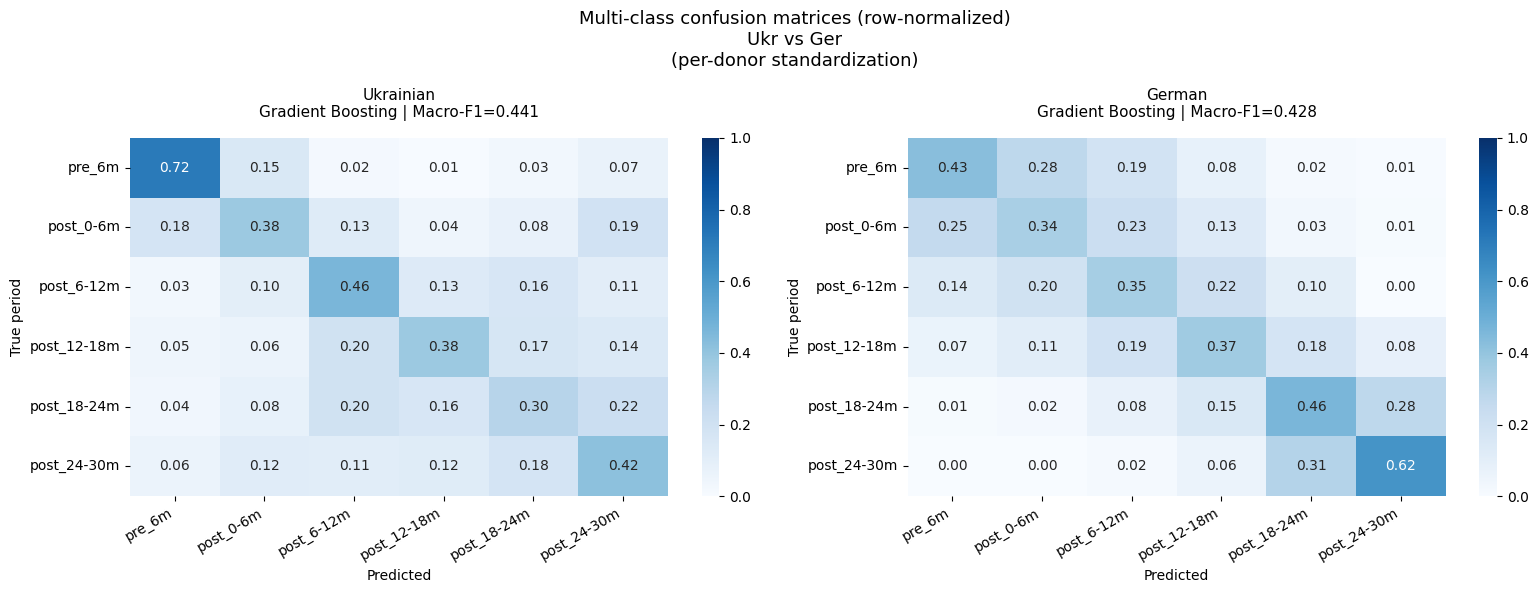

In [16]:
best_model = max(results_ukr, key=lambda m: results_ukr[m]['f1'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (results, group) in zip(axes, [
    (results_ukr, 'Ukrainian'),
    (results_de,  'German'),
]):
    valid  = results[best_model]['valid']
    y_true = results[best_model]['y_true'][valid]
    y_pred = results[best_model]['y_pred'][valid]
    cm = confusion_matrix(y_true, y_pred, labels=window_labels, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=window_labels, yticklabels=window_labels,
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f'{group}\n{best_model} | Macro-F1={results[best_model]["f1"]:.3f}',
                 fontsize=11, pad=15)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True period')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Multi-class confusion matrices (row-normalized)\nUkr vs Ger\n(per-donor standardization)', fontsize=13)
plt.tight_layout()
plt.show()

#### Daily vectors: per-period F1

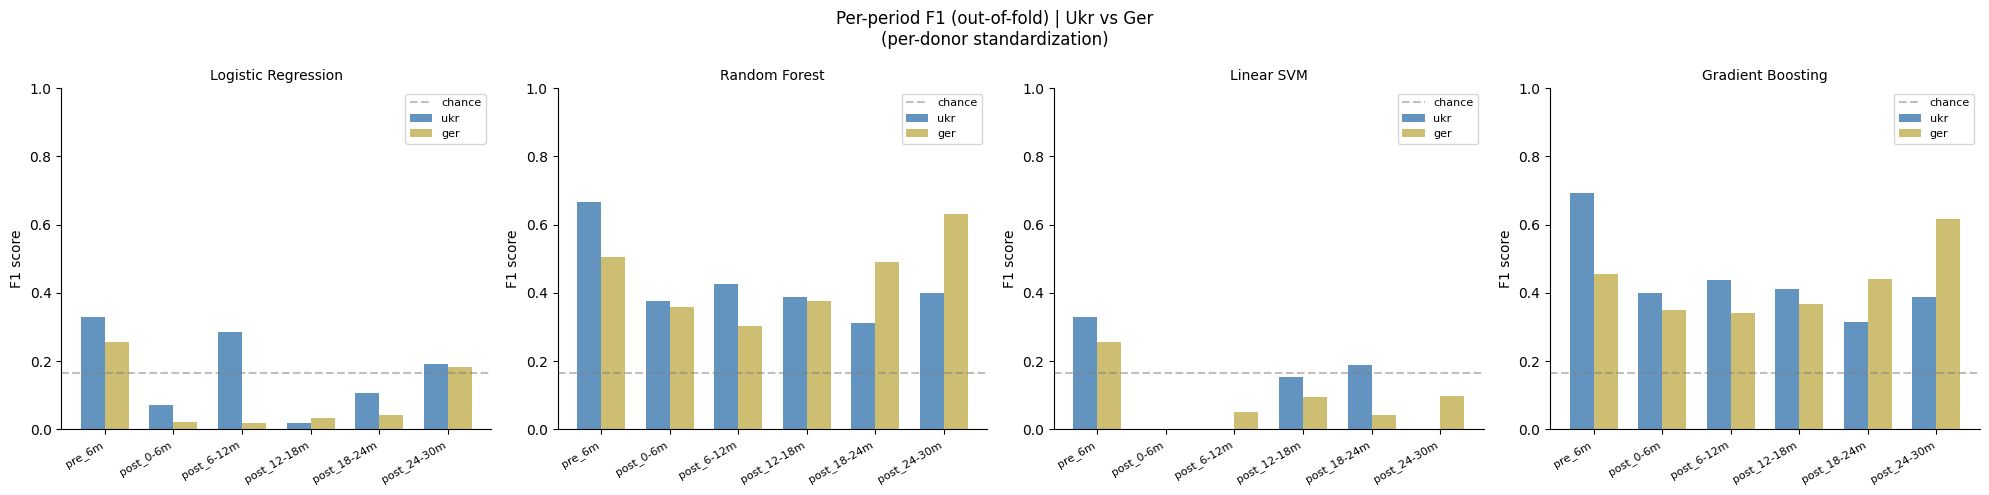

In [17]:
fig, axes = plt.subplots(1, len(models), figsize=(len(models) * 5, 5))

for ax, model_name in zip(axes, models):
    valid_ukr = results_ukr[model_name]['valid']
    valid_de = results_de[model_name]['valid']

    f1_ukr_per = f1_score(results_ukr[model_name]['y_true'][valid_ukr],
                          results_ukr[model_name]['y_pred'][valid_ukr],
                          labels=window_labels, average=None)
    f1_de_per = f1_score(results_de[model_name]['y_true'][valid_de],
                          results_de[model_name]['y_pred'][valid_de],
                          labels=window_labels, average=None)

    x = np.arange(len(window_labels))
    w = 0.35
    ax.bar(x - w/2, f1_ukr_per, w, label='ukr', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, f1_de_per, w, label='ger', color='#C5B358', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(window_labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('F1 score')
    ax.set_title(model_name, fontsize=10)
    ax.axhline(1/6, linestyle='--', color='gray', alpha=0.5, label='chance')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Per-period F1 (out-of-fold) | Ukr vs Ger\n(per-donor standardization)', fontsize=12)
plt.tight_layout()
plt.show()


#### Weekly vectors (42 features)

Vector = 6 daily features × 7 days of the week (Mon–Sun)

In [18]:
day_names = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']
weekly_feature_cols = [f'{feat}_{day}' for feat in features for day in day_names]
print(f'Weekly vector size: {len(weekly_feature_cols)} features')

Weekly vector size: 42 features


In [19]:
def build_weekly_vectors(df_features, features):
    df = df_features.copy()
    df['date'] = pd.to_datetime(df['date'])
    iso = df['date'].dt.isocalendar()
    df['year_week'] = iso['year'].astype(str) + '-W' + iso['week'].astype(str).str.zfill(2)
    df['dayofweek'] = df['date'].dt.dayofweek

    rows = []
    for (donor_id, year_week), grp in df.groupby(['donation_id', 'year_week']):
        row = {'donation_id': donor_id, 'year_week': year_week}
        for feat in features:
            for day_idx, day_name in enumerate(day_names):
                day_rows = grp[grp['dayofweek'] == day_idx]
                row[f'{feat}_{day_name}'] = day_rows[feat].values[0] if len(day_rows) > 0 else 0.0
        rows.append(row)

    return pd.DataFrame(rows)


weekly_ukr = build_weekly_vectors(df_features_ukr, features)
weekly_de = build_weekly_vectors(df_features_de,  features)

print(f'Ukrainian weekly rows: {len(weekly_ukr):,}, donors: {weekly_ukr["donation_id"].nunique()}')
print(f'German weekly rows: {len(weekly_de):,}, donors: {weekly_de["donation_id"].nunique()}')

Ukrainian weekly rows: 4,439, donors: 22
German weekly rows: 8,389, donors: 22


In [20]:
def assign_window_to_week(year_week_str):
    year, week = int(year_week_str.split('-W')[0]), int(year_week_str.split('-W')[1])
    monday = pd.Timestamp.fromisocalendar(year, week, 1)
    for label, start, end in windows:
        if start <= monday < end:
            return label
    return None


weekly_ukr['window'] = weekly_ukr['year_week'].apply(assign_window_to_week)
weekly_de['window'] = weekly_de['year_week'].apply(assign_window_to_week)

weekly_ukr = weekly_ukr.dropna(subset=['window'])
weekly_de = weekly_de.dropna(subset=['window'])

print('Ukrainian window distribution:')
print(weekly_ukr['window'].value_counts().reindex(window_labels))
print('\nGerman window distribution:')
print(weekly_de['window'].value_counts().reindex(window_labels))


Ukrainian window distribution:
window
pre_6m         396
post_0-6m      469
post_6-12m     480
post_12-18m    488
post_18-24m    455
post_24-30m    466
Name: count, dtype: int64

German window distribution:
window
pre_6m         500
post_0-6m      529
post_6-12m     533
post_12-18m    555
post_18-24m    557
post_24-30m    555
Name: count, dtype: int64


In [21]:
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

def prepare_fold_weekly_donor(df_weekly, train_weeks, test_weeks, feat_cols):
    train_raw = df_weekly[df_weekly['year_week'].isin(train_weeks)].copy()
    test_raw = df_weekly[df_weekly['year_week'].isin(test_weeks)].copy()
    train_z = train_raw.copy()
    test_z = test_raw.copy()

    for donor_id in df_weekly['donation_id'].unique():
        mask_train = train_raw['donation_id'] == donor_id
        mask_test = test_raw['donation_id']  == donor_id
        if mask_train.sum() == 0:
            continue

        pre_mask = mask_train & (train_raw['window'] == 'pre_6m')
        if pre_mask.sum() >= 2:
            mean = train_raw.loc[pre_mask, feat_cols].mean().values
            std = train_raw.loc[pre_mask, feat_cols].std().values
        else:
            mean = train_raw.loc[mask_train, feat_cols].mean().values
            std = train_raw.loc[mask_train, feat_cols].std().values
        std[std == 0] = 1

        train_z.loc[mask_train, feat_cols] = (train_raw.loc[mask_train, feat_cols].values - mean) / std
        if mask_test.sum() > 0:
            test_z.loc[mask_test, feat_cols] = (test_raw.loc[mask_test, feat_cols].values - mean) / std

    train_avg = train_z.groupby(['year_week', 'window'])[feat_cols].mean().reset_index()
    test_avg = test_z.groupby(['year_week', 'window'])[feat_cols].mean().reset_index()

    X_train = train_avg[feat_cols].values
    y_train = train_avg['window'].values
    X_test = test_avg[feat_cols].values
    y_test = test_avg['window'].values
    return X_train, y_train, X_test, y_test, test_avg['year_week'].values

In [22]:
def run_multiclass_weekly_donor(df_weekly, feat_cols, group_name):
    week_labels = df_weekly.groupby('year_week')['window'].first().reset_index()
    week_labels = week_labels.sample(frac=1, random_state=42).reset_index(drop=True)
    all_weeks = week_labels['year_week'].values
    all_wins = week_labels['window'].values
    week_to_idx = {w: i for i, w in enumerate(all_weeks)}

    results = {}
    print(f'\n{group_name} — {len(all_weeks)} weeks, {len(feat_cols)} features')

    for name, model in models.items():
        y_pred_all = np.empty(len(all_weeks), dtype=object)
        y_pred_all[:] = None

        for train_idx, test_idx in cv.split(all_weeks, all_wins):
            train_weeks = set(all_weeks[train_idx])
            test_weeks = set(all_weeks[test_idx])

            X_train, y_train, X_test, y_test, test_week_arr = prepare_fold_weekly_donor(
                df_weekly, train_weeks, test_weeks, feat_cols
            )

            if len(X_train) == 0 or len(X_test) == 0:
                continue

            m = clone(model)
            m.fit(X_train, y_train)
            preds = m.predict(X_test)

            for w, p in zip(test_week_arr, preds):
                if w in week_to_idx:
                    y_pred_all[week_to_idx[w]] = p

        valid = np.array([p is not None for p in y_pred_all])
        f1 = f1_score(all_wins[valid], y_pred_all[valid], average='macro')
        acc = (all_wins[valid] == y_pred_all[valid]).mean()
        results[name] = {'y_pred': y_pred_all, 'y_true': all_wins, 'valid': valid, 'f1': f1, 'acc': acc}
        print(f'  {name:<25} accuracy={acc:.3f}  macro-F1={f1:.3f}')
    return results


results_ukr_w = run_multiclass_weekly_donor(weekly_ukr, weekly_feature_cols, 'Ukrainian')
results_de_w = run_multiclass_weekly_donor(weekly_de,  weekly_feature_cols, 'German')



Ukrainian — 156 weeks, 42 features
  Logistic Regression       accuracy=0.199  macro-F1=0.195
  Random Forest             accuracy=0.590  macro-F1=0.584
  Linear SVM                accuracy=0.199  macro-F1=0.196
  Gradient Boosting         accuracy=0.500  macro-F1=0.499

German — 156 weeks, 42 features
  Logistic Regression       accuracy=0.167  macro-F1=0.160
  Random Forest             accuracy=0.660  macro-F1=0.655
  Linear SVM                accuracy=0.199  macro-F1=0.190
  Gradient Boosting         accuracy=0.558  macro-F1=0.552


#### Weekly vectors: confusion matrices

In [23]:
best_model_ukr_w = max(results_ukr_w, key=lambda m: results_ukr_w[m]['f1'])
best_model_de_w = max(results_de_w,  key=lambda m: results_de_w[m]['f1'])

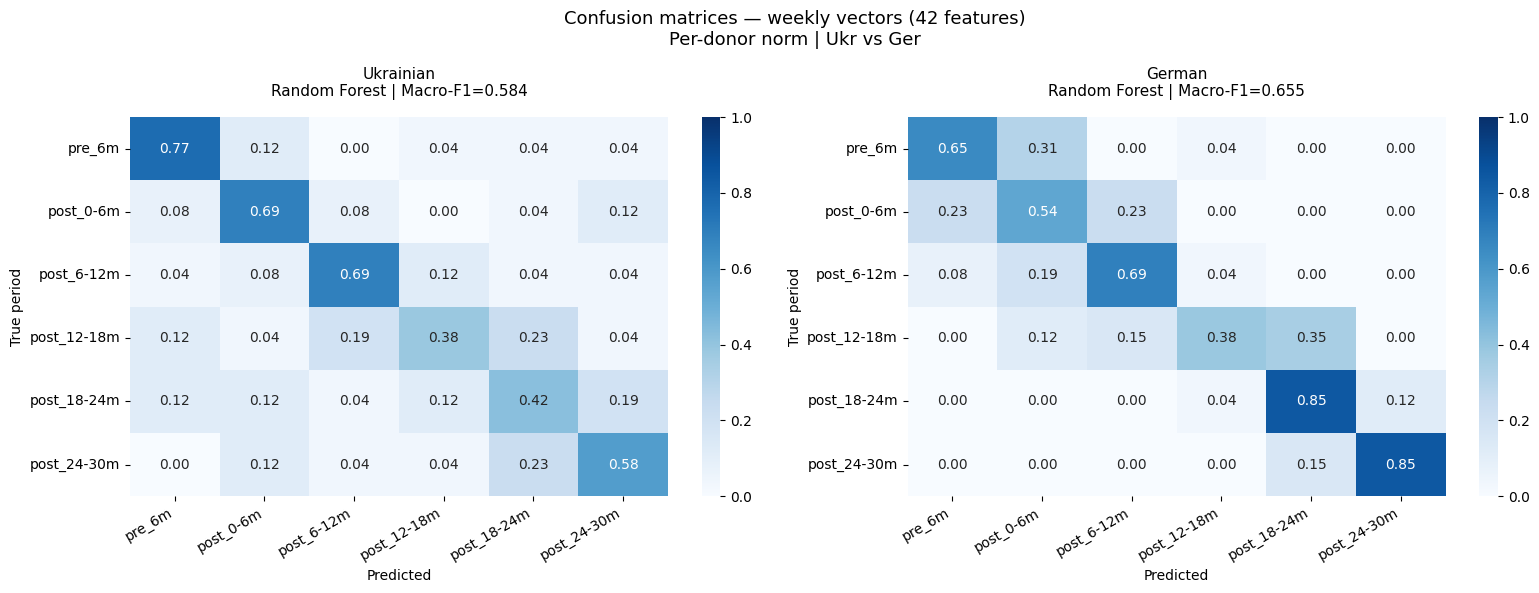

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (results, group, best_model) in zip(axes, [
    (results_ukr_w, 'Ukrainian', best_model_ukr_w),
    (results_de_w, 'German', best_model_de_w),
]):
    valid = results[best_model]['valid']
    y_true = results[best_model]['y_true'][valid]
    y_pred = results[best_model]['y_pred'][valid]
    cm = confusion_matrix(y_true, y_pred, labels=window_labels, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=window_labels, yticklabels=window_labels,
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f'{group}\n{best_model} | Macro-F1={results[best_model]["f1"]:.3f}', fontsize=11, pad=15)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True period')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Confusion matrices — weekly vectors (42 features)\nPer-donor norm | Ukr vs Ger', fontsize=13)
plt.tight_layout()
plt.show()


#### Weekly vectors: per-period F1

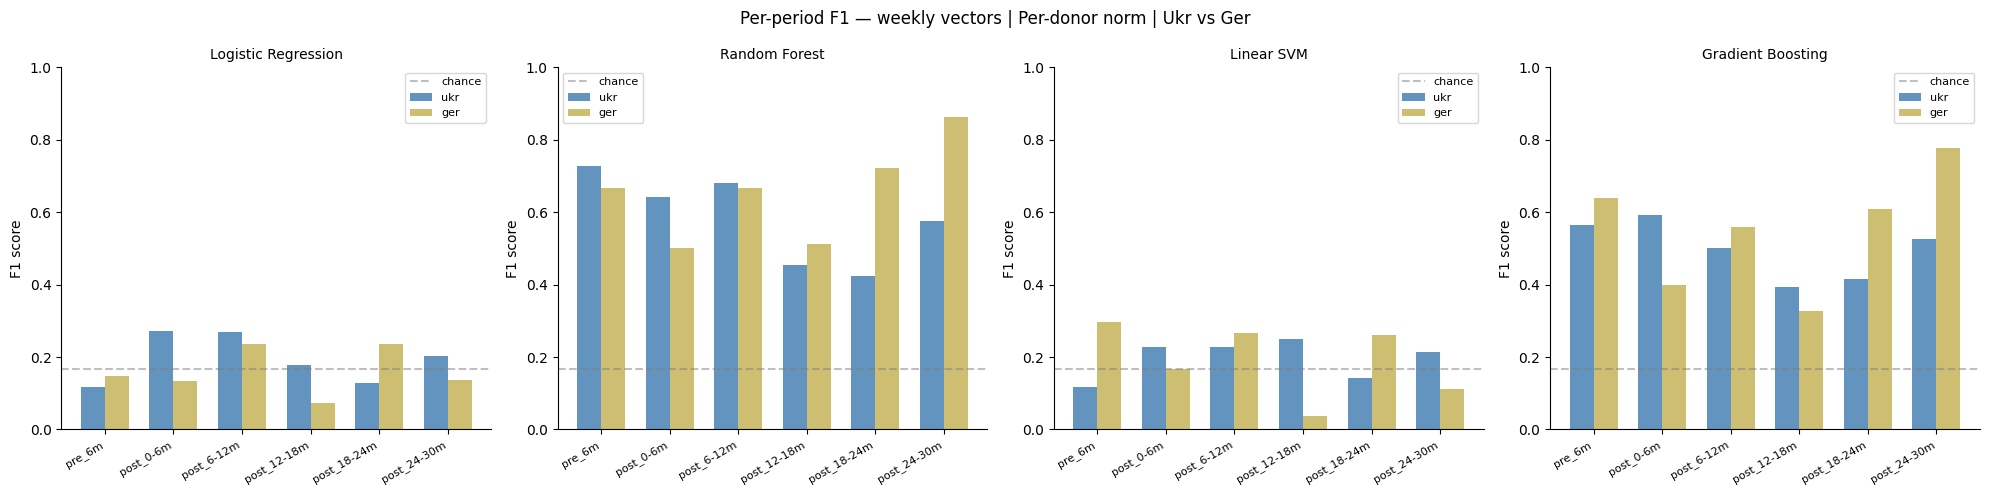

In [25]:
fig, axes = plt.subplots(1, len(models), figsize=(len(models) * 5, 5))

for ax, model_name in zip(axes, models):
    valid_ukr = results_ukr_w[model_name]['valid']
    valid_de  = results_de_w[model_name]['valid']

    f1_ukr_per = f1_score(results_ukr_w[model_name]['y_true'][valid_ukr],
                          results_ukr_w[model_name]['y_pred'][valid_ukr],
                          labels=window_labels, average=None)
    f1_de_per = f1_score(results_de_w[model_name]['y_true'][valid_de],
                          results_de_w[model_name]['y_pred'][valid_de],
                          labels=window_labels, average=None)

    x = np.arange(len(window_labels))
    w = 0.35
    ax.bar(x - w/2, f1_ukr_per, w, label='ukr', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, f1_de_per,  w, label='ger', color='#C5B358', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(window_labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('F1 score')
    ax.set_title(model_name, fontsize=10)
    ax.axhline(1/6, linestyle='--', color='gray', alpha=0.5, label='chance')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Per-period F1 — weekly vectors | Per-donor norm | Ukr vs Ger', fontsize=12)
plt.tight_layout()
plt.show()
